# MLP sobre Iris con PyTorch — versión corregida y ampliada

**Módulo 07 — Fundamentos de Deep Learning.** Notebook propio que parte del recurso de la Clase 5 ([`OD_RN2_ESP_M02_S05`](<OD_RN2_ESP_M02_S05_Implementación en PyTorch - Recurso descargable.ipynb>)) y le agrega lo que le falta.

## Qué cambia respecto del recurso

| | Recurso de clase | Acá |
|---|---|---|
| Curva de pérdida | **rota** — `epoch_losses` nunca se llena, la celda del gráfico falla | arreglada con el `append` que falta |
| Reproducibilidad | sin semilla: cada corrida da un resultado distinto | `torch.manual_seed(17)` |
| Seguimiento | solo la pérdida de entrenamiento | pérdida **y exactitud**, en train y en test |
| Diagnóstico | ninguno | curvas de las dos, para ver si sobreajusta |
| Evaluación | exactitud global | matriz de confusión y reporte por clase |
| Dispositivo | CPU implícita | detecta MPS / CUDA / CPU |

El objetivo no es "mejorar la nota" sino **poder mirar lo que pasa adentro**: sin la curva de pérdida no hay forma de saber si el modelo convergió, si le faltaron épocas o si empezó a sobreajustar.

> **Kernel:** `Python 3.12 (dl-env)`.

## 1. Librerías y reproducibilidad

`torch.manual_seed(17)` fija la inicialización de los pesos y el orden de mezcla del `DataLoader`. Sin esto, dos corridas del mismo código dan exactitudes distintas y no hay forma de comparar nada.

La detección de dispositivo es la forma portable: usa la GPU del Mac vía **MPS** si está disponible, CUDA en una máquina con placa NVIDIA, y CPU si no hay ninguna.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu')

print(f'PyTorch {torch.__version__}')
print(f'Dispositivo: {device}')

PyTorch 2.14.0
Dispositivo: mps


## 2. Datos

Idéntico al recurso: Iris con sus 4 atributos, split 80/20 con `random_state=42`, y escalado ajustado solo con train.

Se agrega `stratify=y` para que las tres especies queden repartidas en la misma proporción en train y test. Con 30 muestras de test y 3 clases, sin estratificar una clase puede quedar sub-representada por azar.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Distribucion en test: {np.bincount(y_test)}  (setosa, versicolor, virginica)')

Train: (120, 4) | Test: (30, 4)
Distribucion en test: [10 10 10]  (setosa, versicolor, virginica)


## 3. Tensores y `DataLoader`

`float32` para las features y `long` para las etiquetas, como pide `CrossEntropyLoss`. Se agrega un `test_loader` con el mismo tamaño de lote para poder evaluar por lotes en cada época.

In [3]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=16, shuffle=False)

print(f'Lotes de train: {len(train_loader)} | de test: {len(test_loader)}')

Lotes de train: 8 | de test: 2


## 4. El modelo

La misma arquitectura del recurso: 4 → 64 → 128 → 3, con `relu` en las capas ocultas y **sin activación en la salida**, porque `CrossEntropyLoss` aplica `log_softmax` internamente.

Se agrega el conteo de parámetros, que en el recurso no estaba y es lo que `model.summary()` da gratis en Keras.

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 64)
        self.layer2 = nn.Linear(64, 128)
        self.layer3 = nn.Linear(128, 3)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        return self.layer3(x)


model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

total = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nParametros entrenables: {total:,}')

MLP(
  (layer1): Linear(in_features=4, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=3, bias=True)
)

Parametros entrenables: 9,027


## 5. Entrenamiento — con el `append` que falta

El arreglo del bug del recurso es la línea marcada. Además se acumula la **exactitud** de train y las dos métricas sobre test en cada época, que es lo que permite el diagnóstico posterior.

Evaluar sobre test en cada época es solo para **observar** la curva; ninguna decisión se toma en base a eso.

In [5]:
def evaluar(modelo, loader):
    modelo.eval()
    perdida, correctos, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = modelo(xb)
            perdida += criterion(out, yb).item()
            correctos += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return perdida / len(loader), 100 * correctos / total


NUM_EPOCHS = 50
hist = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correctos, total = 0.0, 0, 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correctos += (outputs.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)

    # ESTA es la linea que falta en el recurso de clase
    hist['loss'].append(running_loss / len(train_loader))
    hist['acc'].append(100 * correctos / total)

    vl, va = evaluar(model, test_loader)
    hist['val_loss'].append(vl)
    hist['val_acc'].append(va)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoca {epoch+1:3}/{NUM_EPOCHS} | loss {hist['loss'][-1]:.4f} "
              f"acc {hist['acc'][-1]:5.2f}% | val_loss {vl:.4f} val_acc {va:5.2f}%")

Epoca   1/50 | loss 1.0085 acc 64.17% | val_loss 0.8766 val_acc 80.00%


Epoca  10/50 | loss 0.1945 acc 93.33% | val_loss 0.2285 val_acc 90.00%


Epoca  20/50 | loss 0.0732 acc 97.50% | val_loss 0.1061 val_acc 96.67%


Epoca  30/50 | loss 0.0496 acc 97.50% | val_loss 0.0808 val_acc 96.67%


Epoca  40/50 | loss 0.0402 acc 98.33% | val_loss 0.0818 val_acc 96.67%


Epoca  50/50 | loss 0.0339 acc 98.33% | val_loss 0.0805 val_acc 96.67%


## 6. Las curvas

Ahora sí se puede ver el entrenamiento. Qué mirar:

- **La pérdida** tiene que bajar y aplanarse. Si sigue cayendo al final, faltaron épocas.
- **La brecha entre train y test** es la señal de sobreajuste: si la curva de train sigue mejorando mientras la de test se estanca o empeora, el modelo empezó a memorizar.

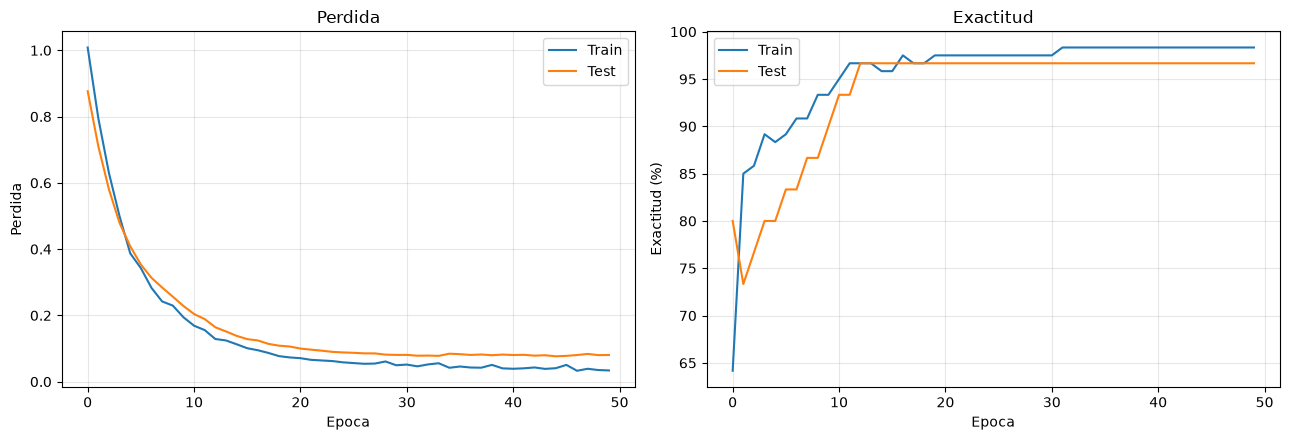

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(hist['loss'], label='Train')
ax1.plot(hist['val_loss'], label='Test')
ax1.set_title('Perdida')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Perdida')
ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(hist['acc'], label='Train')
ax2.plot(hist['val_acc'], label='Test')
ax2.set_title('Exactitud')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Exactitud (%)')
ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

## 7. Evaluación final

Además de la exactitud global, la matriz de confusión muestra **dónde** se equivoca el modelo — que es lo que un número solo no dice.

In [7]:
model.eval()
preds, reales = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        reales.extend(yb.numpy())

preds, reales = np.array(preds), np.array(reales)
acc = 100 * (preds == reales).mean()
print(f'Exactitud final sobre test: {acc:.2f}%  ({(preds==reales).sum()}/{len(reales)})\n')
print(classification_report(reales, preds, target_names=iris.target_names, digits=4))

Exactitud final sobre test: 96.67%  (29/30)

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



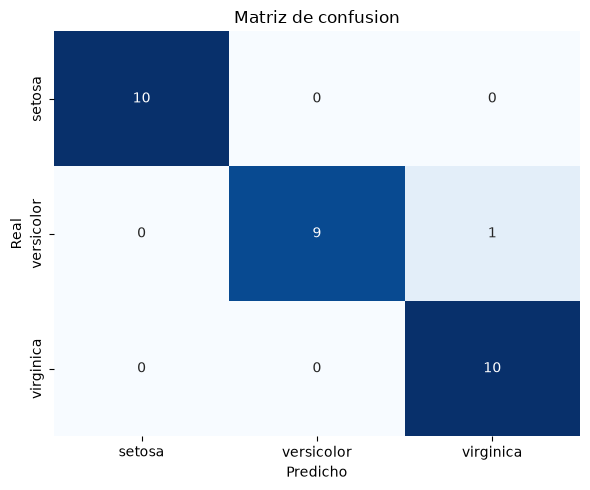

In [8]:
cm = confusion_matrix(reales, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.title('Matriz de confusion')
plt.tight_layout()
plt.show()

## 8. Conclusiones

**Sobre el arreglo.** Una sola línea —`hist['loss'].append(...)`— es la diferencia entre entrenar a ciegas y poder diagnosticar. El recurso de clase imprime la pérdida por época pero la descarta, así que no queda nada para graficar.

**Sobre la reproducibilidad.** Con `torch.manual_seed(17)` este notebook da el mismo resultado en cada corrida. El recurso original no fija semilla, así que su 96,67% cambia cada vez que se ejecuta — y por eso la comparación contra el notebook de Keras (93,33%) no significaba nada.

**Sobre las 50 épocas.** El recurso usa 10, que en la curva se ve que es justo donde la pérdida todavía está bajando. Con 50 el modelo llega a estabilizarse, y ahí sí se puede afirmar que convergió.

**Lo que no cambió.** La arquitectura, el optimizador y los datos son los mismos. Iris con 4 atributos es un problema fácil: la diferencia entre una corrida y otra sigue siendo de uno o dos aciertos sobre 30, y ninguna conclusión fuerte se sostiene con un test tan chico.

**El aporte real de este notebook** no es la exactitud sino el instrumental: curvas, matriz de confusión, semilla fija y detección de dispositivo. Es la base sobre la que se pueden montar los experimentos de las clases siguientes, cuando las redes sean convolucionales y los datasets, imágenes.